# Monthly RMS

In [1]:
import xarray as xr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches
from tqdm import tqdm

In [2]:
rms = xr.open_mfdataset('RMS_dweighted/RMS_*.nc')
rms = rms.compute()
rms

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 262, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    RMS      (time, lat, lon) float64 1GB nan nan nan nan ... nan nan nan nan

In [3]:
rms.drop_encoding().to_netcdf('RMS_d_weighted.nc')

In [4]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

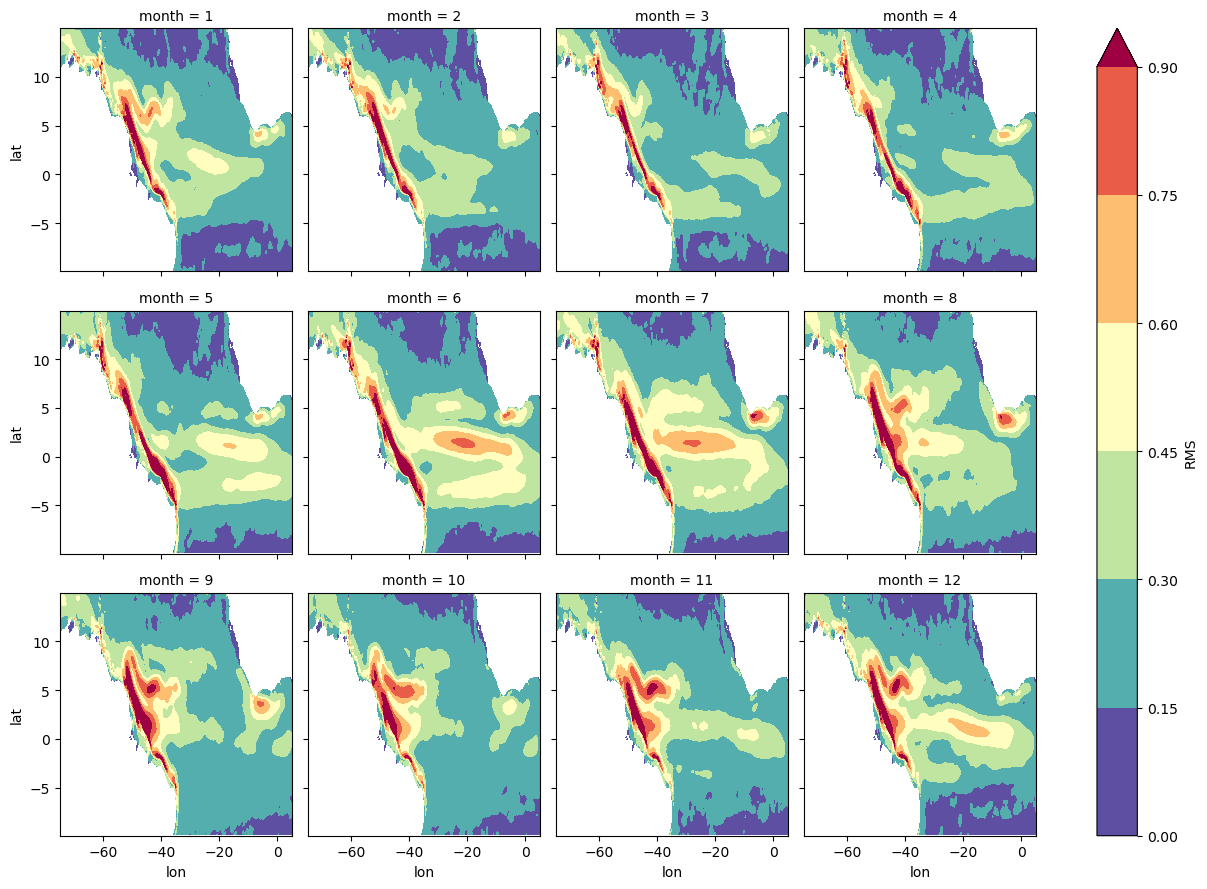

In [5]:
seasonality(rms).sel(lon=slice(-75,5),lat=slice(-10,15)).RMS.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,robust=True,cmap='Spectral_r')

In [6]:
months = rms.time.dt.month

month_to_season = {
    10: 'OND', 11: 'OND', 12: 'OND',
    1: 'JFM', 2: 'JFM', 3: 'JFM',
    4: 'AMJ', 5: 'AMJ', 6: 'AMJ',
    7: 'JAS', 8: 'JAS', 9: 'JAS',
}

# Map to season labels
season_labels = xr.apply_ufunc(
    np.vectorize(month_to_season.get),
    months,
    dask='parallelized',
    output_dtypes=[object]
)

# Groupby season and compute (e.g. mean)
rms_seasonal = rms.groupby(season_labels).mean('time')
rms_seasonal

<xarray.Dataset> Size: 20MB
Dimensions:  (month: 4, lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * month    (month) object 32B 'AMJ' 'JAS' 'JFM' 'OND'
Data variables:
    RMS      (month, lat, lon) float64 20MB nan nan nan nan ... nan nan nan nan

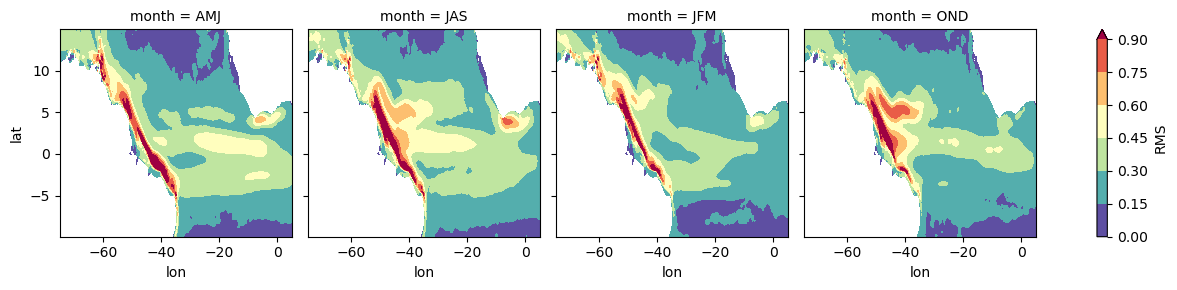

In [7]:
rms_seasonal.sel(lon=slice(-75,5),lat=slice(-10,15)).RMS.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,robust=True,cmap='Spectral_r')

In [8]:
seasonality(rms)

<xarray.Dataset> Size: 60MB
Dimensions:  (month: 12, lat: 499, lon: 1260)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    RMS      (month, lat, lon) float64 60MB nan nan nan nan ... nan nan nan nan

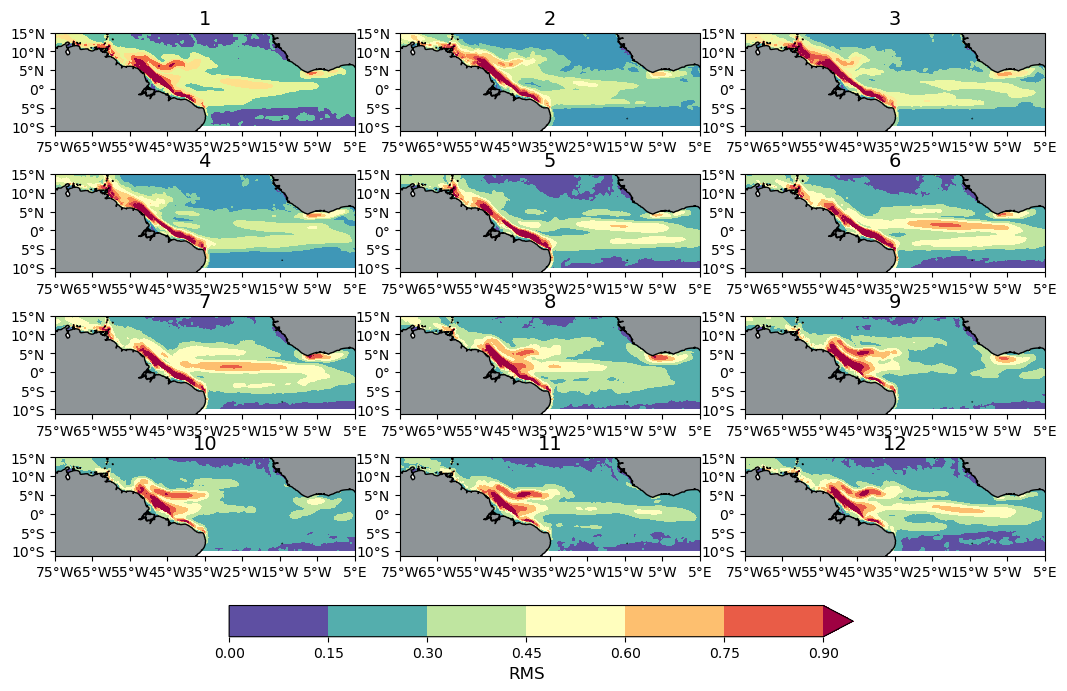

In [9]:
rms_seasons = seasonality(rms).sel(lon=slice(-75,5),lat=slice(-10,15))
seasons = rms_seasons.month.values  # or whatever the season dim is called

fig, ax = plt.subplots(
    4, 3, figsize=(11, 8),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)
ax = ax.ravel()

for i, season in enumerate(seasons):
    dd = rms_seasons.sel(month=season)['RMS']

    # Plot
    pcm = dd.plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
        add_colorbar=False, cmap='Spectral_r', robust=True
    )
    
    ax[i].coastlines()
    ax[i].set_title(season, fontsize=14)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    
    # Ticks
    ax[i].set_xticks(
        np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
        crs=ccrs.PlateCarree()
    )
    ax[i].set_yticks(
        np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
        crs=ccrs.PlateCarree()
    )
    ax[i].xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].tick_params(labelsize=10)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

# Adjust spacing
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.9, wspace=0.15)

# Add shared colorbar
cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.08)
cbar.set_label('RMS', fontsize=12)

plt.show()

### Following Dippner 2024
* NBC retroflection: 10-7N, 55-51W

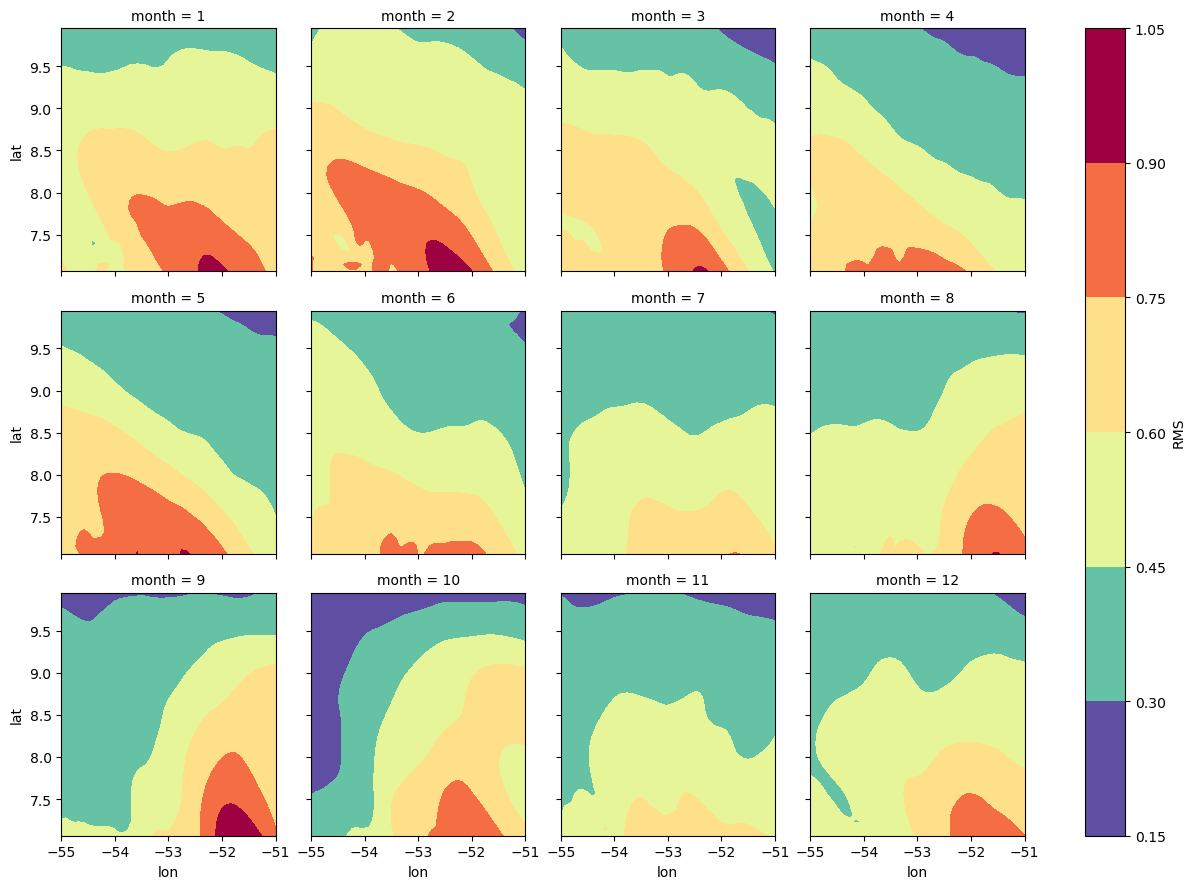

In [10]:
NBC_dippner = seasonality(rms)
NBC_dippner.sel(lon=slice(-55,-51), lat=slice(7,10)).RMS.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,cmap='Spectral_r')

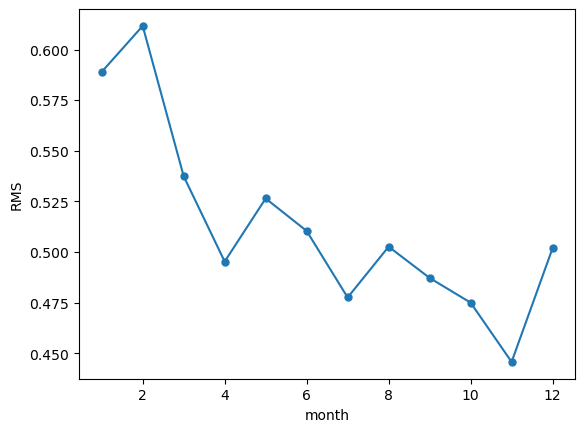

In [11]:
NBC_dippner.sel(lon=slice(-55,-51), lat=slice(7,10)).RMS.mean(dim=('lat','lon')).plot(linestyle='-',marker='.',markersize=10)

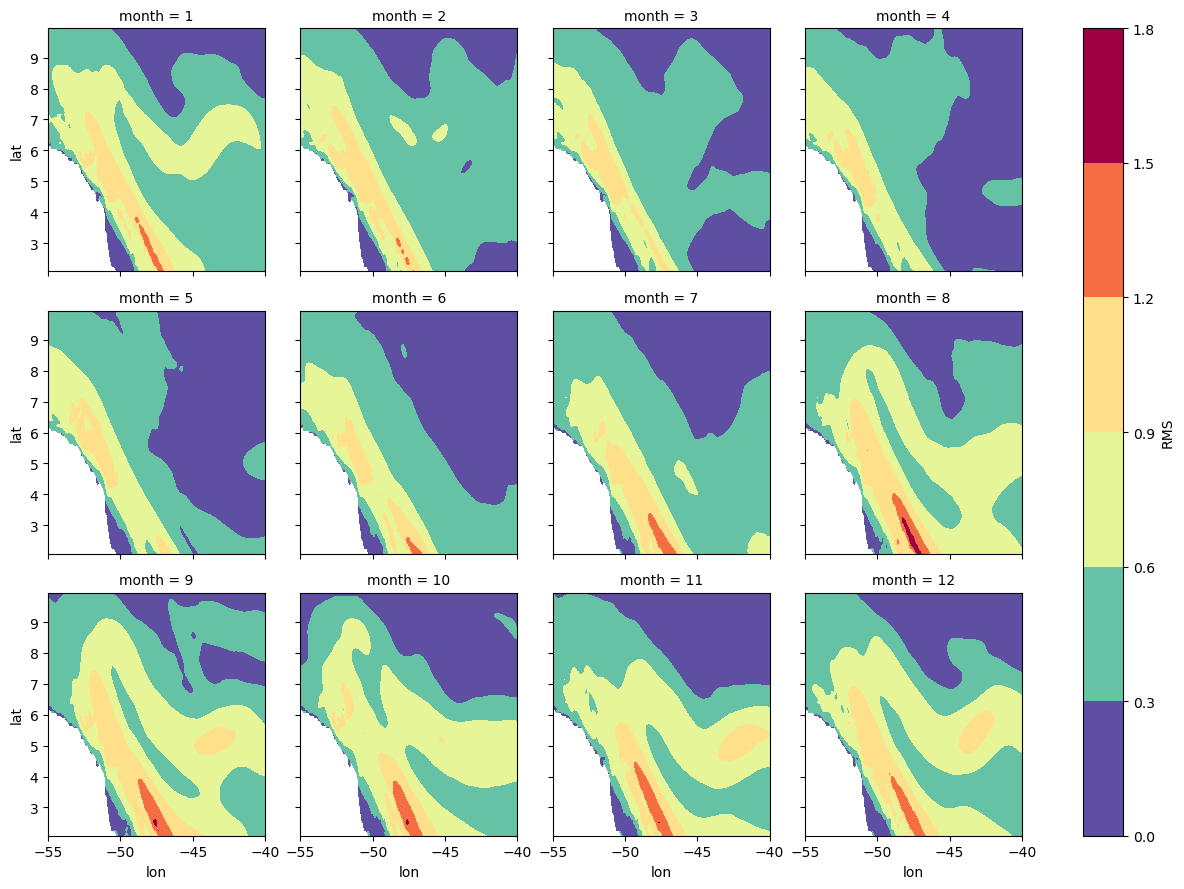

In [12]:
NBC= seasonality(rms)
NBC.sel(lon=slice(-55,-40), lat=slice(2,10)).RMS.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,cmap='Spectral_r')

Text(0.5, 1.0, 'RM of 7 meter water velocity')

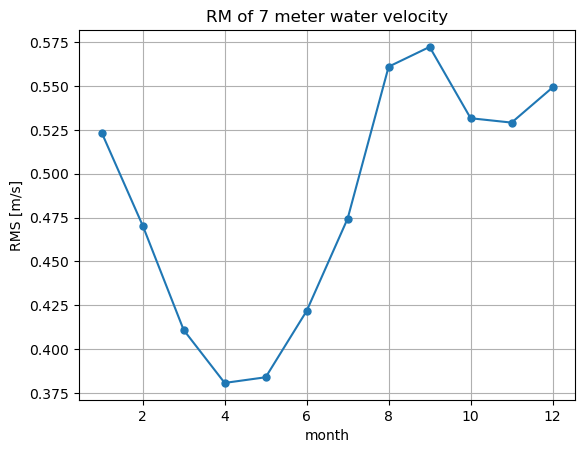

In [13]:
NBC.sel(lon=slice(-55,-40), lat=slice(2,10)) \
    .RMS.mean(dim=('lat','lon')).rename('RMS [m/s]')\
    .plot(linestyle='-',marker='.',markersize=10)
plt.grid()
plt.title('RM of 7 meter water velocity') 

In [14]:
UV_ = xr.open_dataset('UV_0_7m.nc')
UV_ = UV_.compute()
UV_

<xarray.Dataset> Size: 20GB
Dimensions:  (time: 7973, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    UV       (time, lat, lon) float32 20GB nan nan nan nan ... nan nan nan nan

Text(0.5, 1.0, '7 meter water velocity')

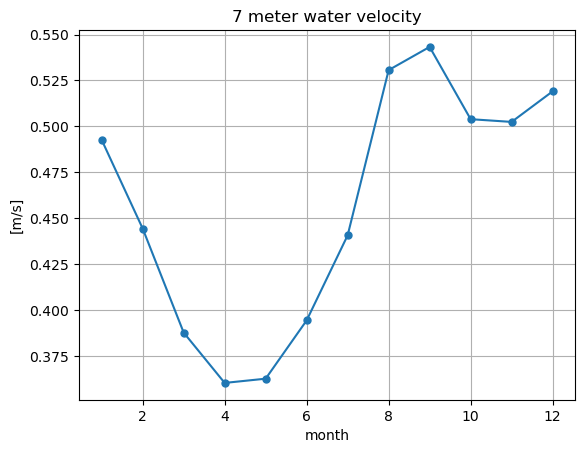

In [15]:
UV_m = seasonality(UV_.resample(time='MS').mean())
UV_m.UV.sel(lon=slice(-55,-40), lat=slice(2,10)) \
    .mean(dim=('lat','lon')).rename('[m/s]')\
    .plot(linestyle='-',marker='.',markersize=10)
plt.grid()
plt.title('7 meter water velocity') 

#### Variance calculation

The standard deviation of speed can be obtained from the mean speed and RMS speed:

$$
\sigma_s = \sqrt{s_{\mathrm{rms}}^{2} - \langle s \rangle^{2}}
$$

where
- $$s(t) = \sqrt{U(t)^2 + V(t)^2}$$
- $$\langle s \rangle = \left\langle \sqrt{U^2+V^2} \right\rangle_t$$ is the time-mean speed
- $$s_{\mathrm{rms}} = \sqrt{\langle U^2+V^2\rangle_t} = \sqrt{\langle s^2\rangle_t}$$ is the RMS speed.

In [16]:
# rms
UV__ = UV_.resample(time='MS').mean()
UV__

<xarray.Dataset> Size: 664MB
Dimensions:  (lat: 499, lon: 1260, time: 264)
Coordinates:
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
  * time     (time) datetime64[ns] 2kB 1993-01-01 1993-02-01 ... 2014-12-01
Data variables:
    UV       (time, lat, lon) float32 664MB nan nan nan nan ... nan nan nan nan

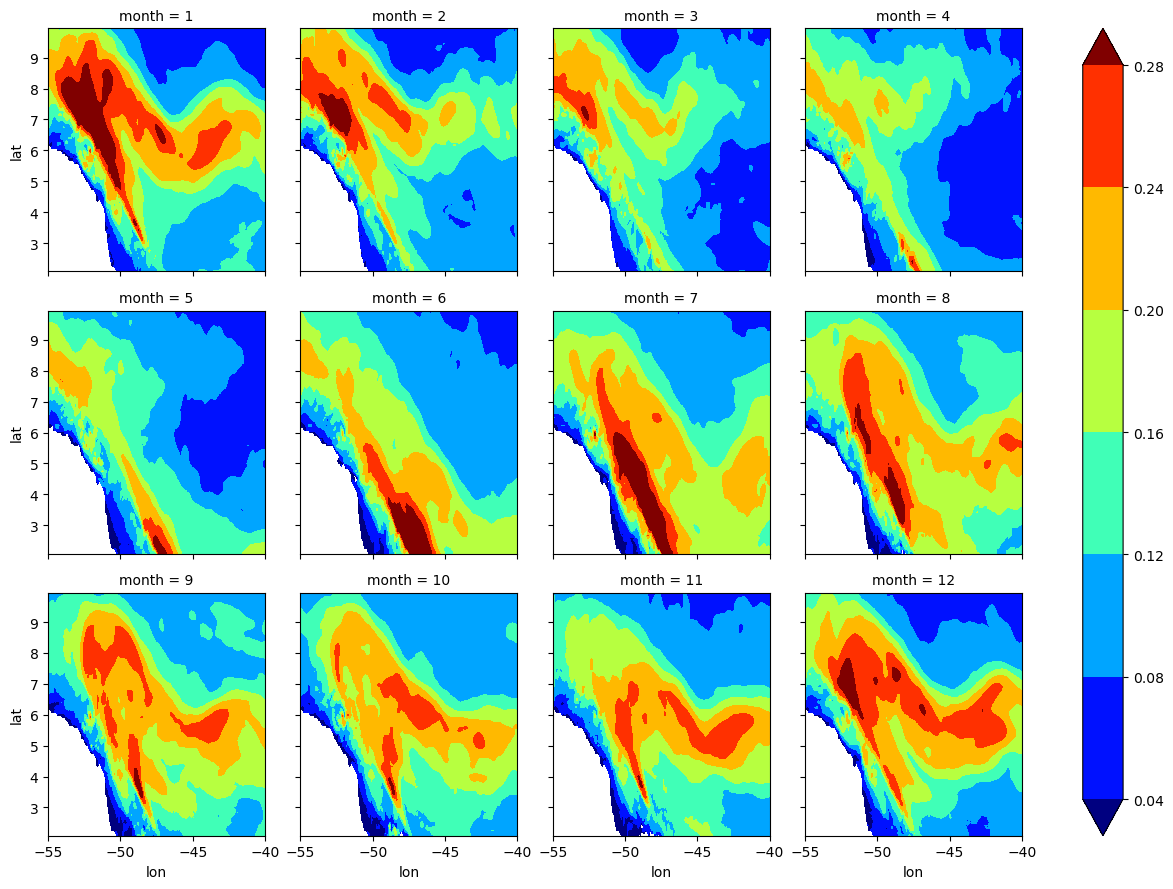

In [17]:
var_ = seasonality((rms.RMS**2 - UV__.UV**2)**0.5) #variance
var_.sel(lon=slice(-55,-40), lat=slice(2,10)).plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,cmap='jet',robust=True)

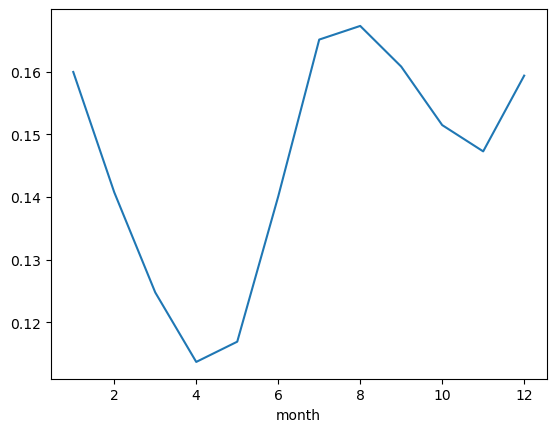

In [18]:
var_.sel(lon=slice(-55,-40), lat=slice(2,10)).mean(dim=('lat','lon')).plot()

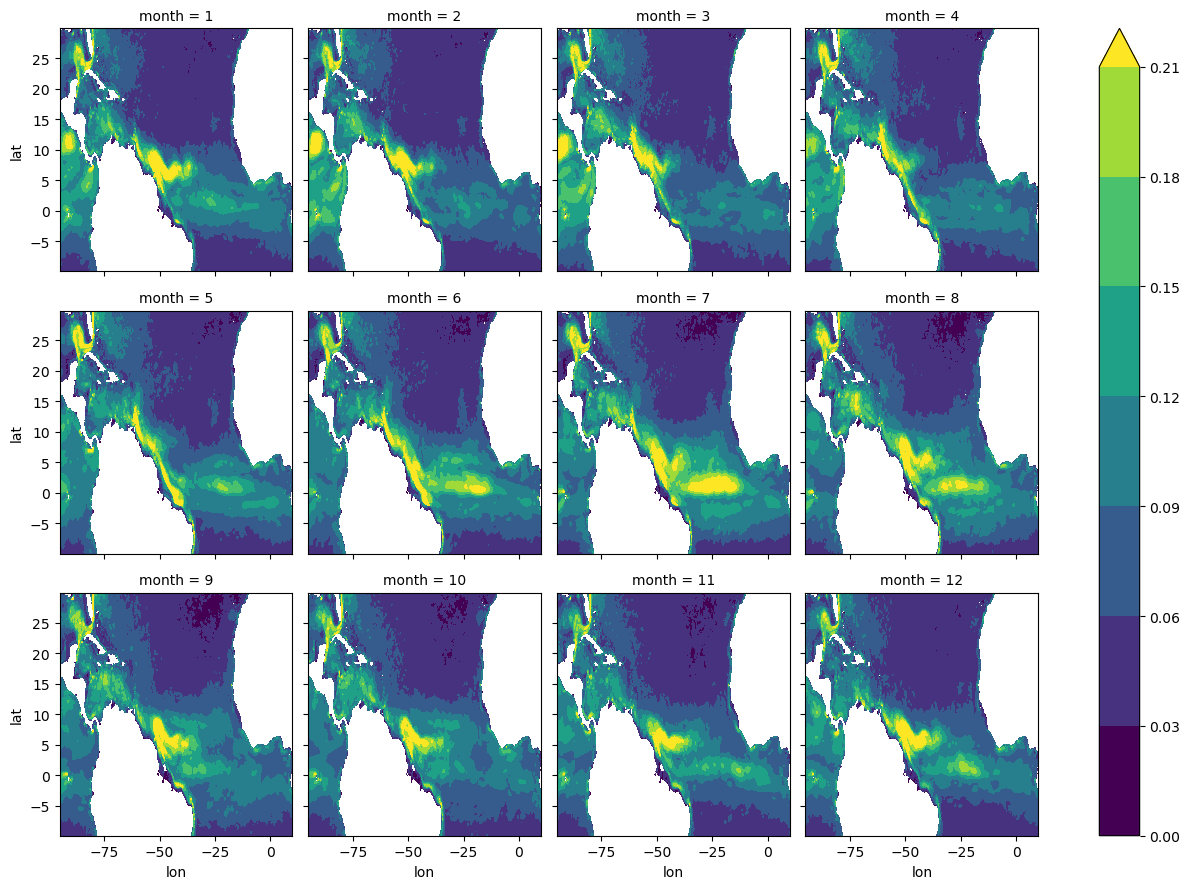

In [19]:
var_.plot.contourf(
    x="lon", y="lat", col="month", col_wrap=4,cmap='viridis',robust=True)

## Particle Tracking

In [20]:
hist_month = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/_hist_month.nc").compute().histogram_lon_lat
hist_month

<xarray.DataArray 'histogram_lon_lat' (start_month: 12, obs: 37, lon: 79,
                                       lat: 29)> Size: 8MB
array([[[[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
...
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,   83,    0,    0],
         [   0,    0,    0, ...,  736,  272,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    8,    0,    0],
         [   0,    0,    0, ...,  156,   19,    0],
         [   0,    0,    0, ..., 1216,  262,    8],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]]]],
      shape=(12, 37, 79, 29))
Coordinates:
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


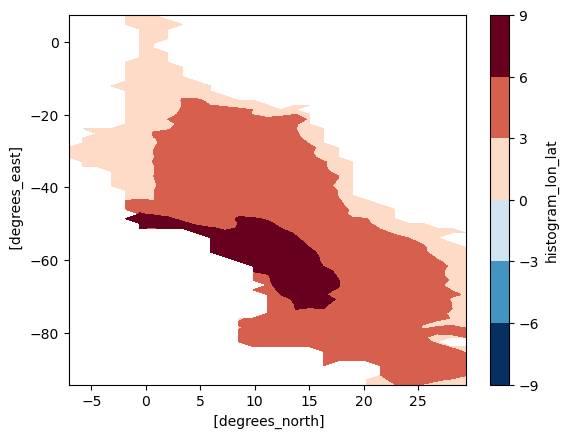

In [21]:
np.log10(hist_month.std('start_month').sum('obs')).plot.contourf()

In [22]:
# months = hist_month.start_month

# month_to_season = {
#     10: 'OND', 11: 'OND', 12: 'OND',
#     1: 'JFM', 2: 'JFM', 3: 'JFM',
#     4: 'AMJ', 5: 'AMJ', 6: 'AMJ',
#     7: 'JAS', 8: 'JAS', 9: 'JAS',
# }

# # Map to season labels
# season_labels = xr.apply_ufunc(
#     np.vectorize(month_to_season.get),
#     months,
#     dask='parallelized',
#     output_dtypes=[object]
# )


# hist_season = hist_month.groupby(season_labels).sum('obs')
# hist_season

months = hist_month.start_month

month_to_season = {
    10: 'OND', 11: 'OND', 12: 'OND',
    1: 'JFM', 2: 'JFM', 3: 'JFM',
    4: 'AMJ', 5: 'AMJ', 6: 'AMJ',
    7: 'JAS', 8: 'JAS', 9: 'JAS',
}

# Map to season labels
season_labels = xr.apply_ufunc(
    np.vectorize(month_to_season.get),
    months,
    dask='parallelized',
    output_dtypes=[object]
)

# Assign season_labels as a coordinate
hist_month_with_season = hist_month.assign_coords(
    season=('start_month', season_labels.data)
)

# Now groupby season and sum over start_month
hist_season = hist_month_with_season.groupby('season').sum('start_month')

hist_season

<xarray.DataArray 'histogram_lon_lat' (season: 4, obs: 37, lon: 79, lat: 29)> Size: 3MB
array([[[[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
...
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,   148,    14,   557],
         [    0,     0,     0, ...,  1094,   440,   986],
         [    0,     0,     0, ..., 12209,  7860,  1203],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,   209,    65,   730],
         [    0,     0,     0, ...,  1621,  1103,  1402],
         [    0,     0,     0, ..., 11692, 10446,  1392],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]]]],
      shape=(4, 37, 79, 29))
Coordinates:
  * obs      (obs) float64 296B 10.5 30.5 50.5 70.5 ... 670.5 690.5 710.5 730.5
  * lon      (lon) float64 632B -94.31 -93.0 -91.7 -90.4 ... 4.776 6.08 7.384
  * lat      (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * season   (season) object 32B 'AMJ' 'JAS' 'JFM' 'OND'

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/tmp/ipykernel_1955883/3903315726.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


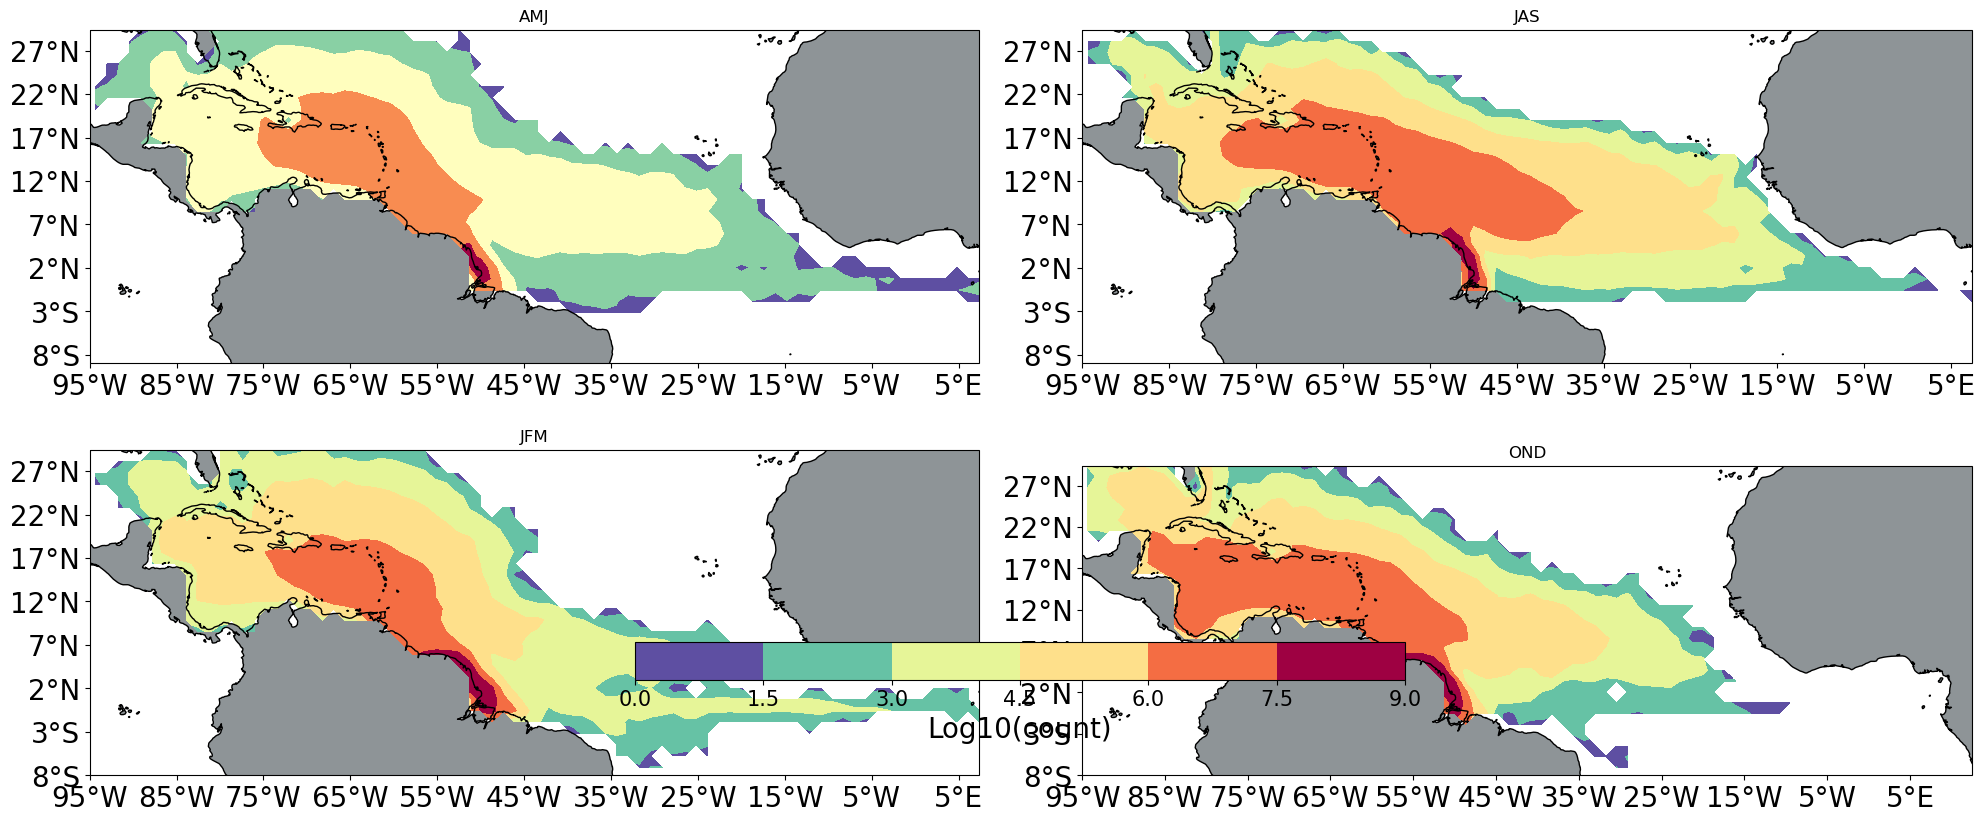

In [33]:
seasons = ['AMJ','JAS','JFM','OND']

fig, ax = plt.subplots(2, 2, figsize=(20, 10),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(len(seasons)):
    dd = hist_season.sel(season=str(seasons[i])).sum("obs")

    pcm = np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
        add_colorbar=False, cmap='Spectral_r'
    )
    ax[i].coastlines()
    ax[i].set_title(seasons[i], fontsize=12)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].tick_params(labelsize=20)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

fig.subplots_adjust(wspace=0.2, hspace=-0.5)

cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10,
)
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_xlabel('Log10(count)', fontsize=20)

plt.tight_layout()
# plt.savefig("seasonality_subplots_45678.png", dpi=300, bbox_inches="tight")
plt.show()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


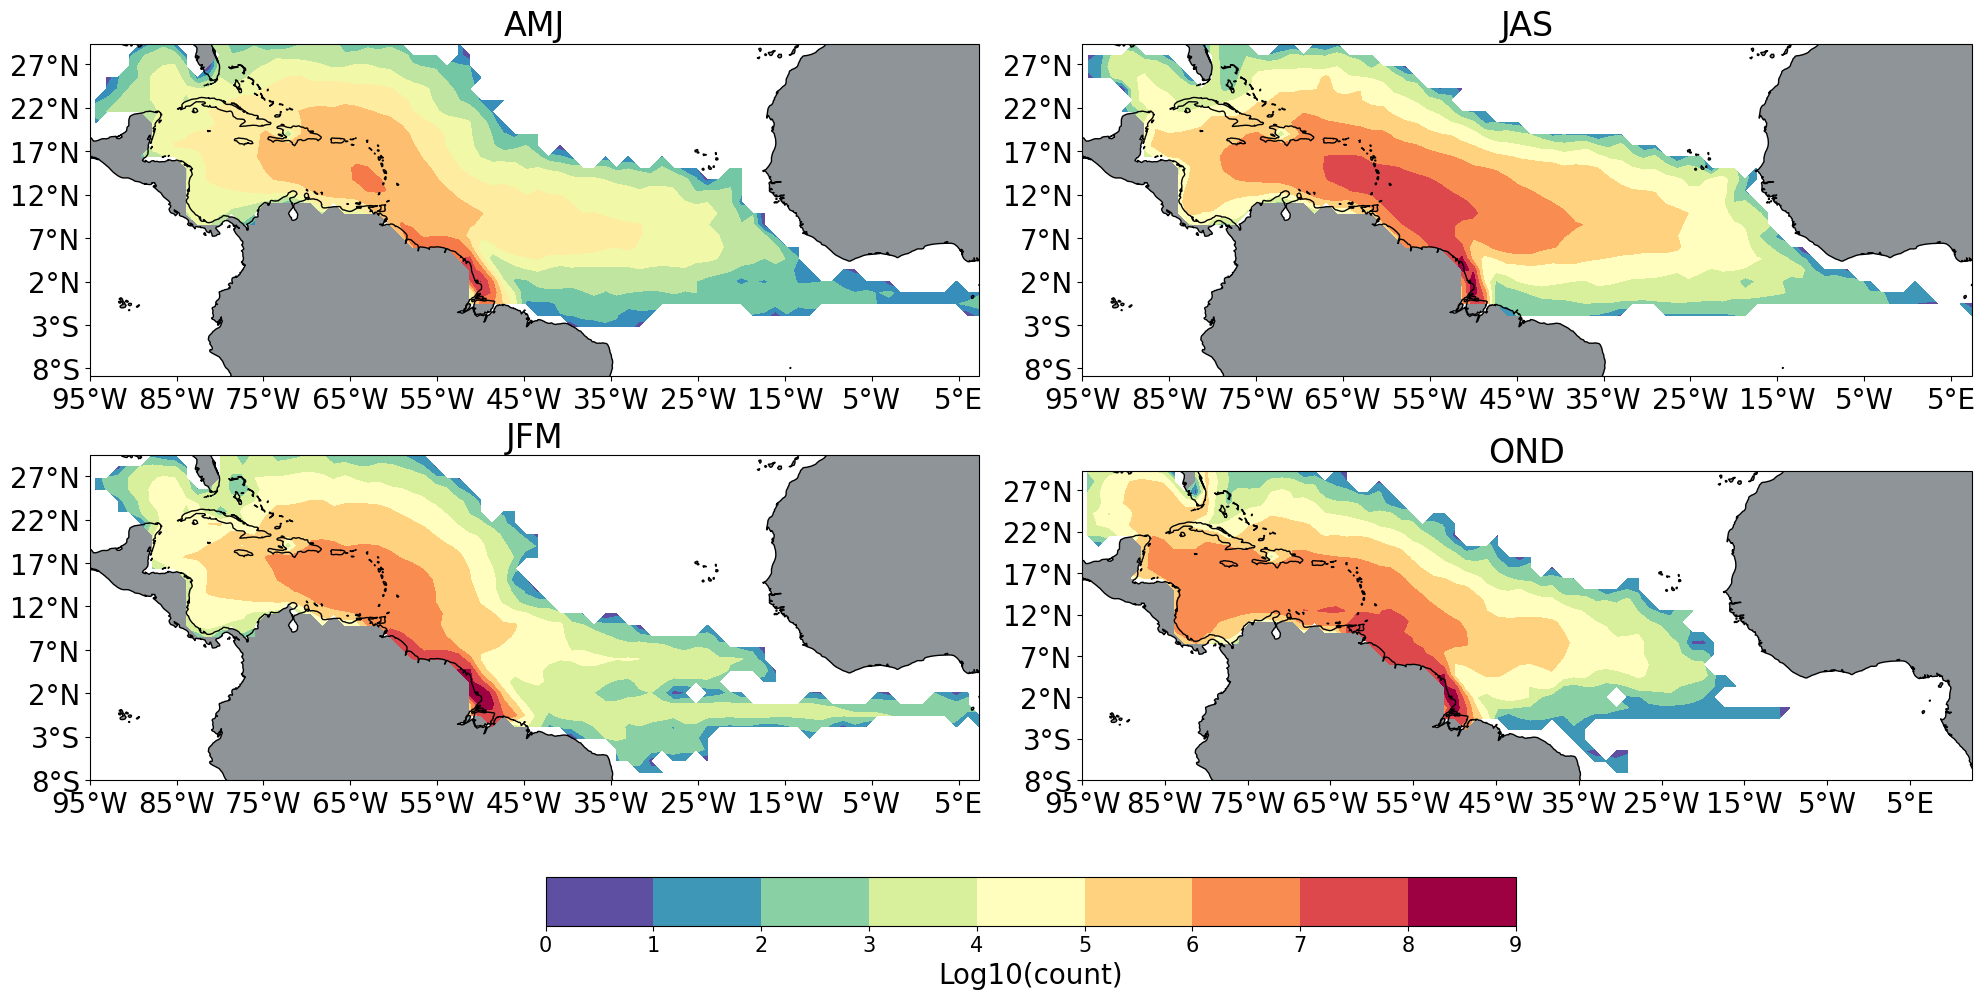

In [37]:
seasons = ['AMJ','JAS','JFM','OND']

fig, ax = plt.subplots(2, 2, figsize=(20, 10),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()


for i in range(len(seasons)):
    # counts = hist_season.sel(season=str(seasons[i])).sum("obs")
    dd = hist_season.sel(season=str(seasons[i])).sum("obs")
    # plot
    # dd = dd.where(dd!=0,np.nan)
    pcm = np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
        add_colorbar=False, cmap='Spectral_r',levels=11
    )

    ax[i].coastlines()
    ax[i].set_title(seasons[i], fontsize=24)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].tick_params(labelsize=20)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

fig.subplots_adjust(wspace=0.2, hspace=0.1)
plt.tight_layout()
# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10,
)
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_xlabel('Log10(count)', fontsize=20)
# plt.savefig("seasonality_subplots_particle_density.png", dpi=300, bbox_inches="tight")
plt.show()

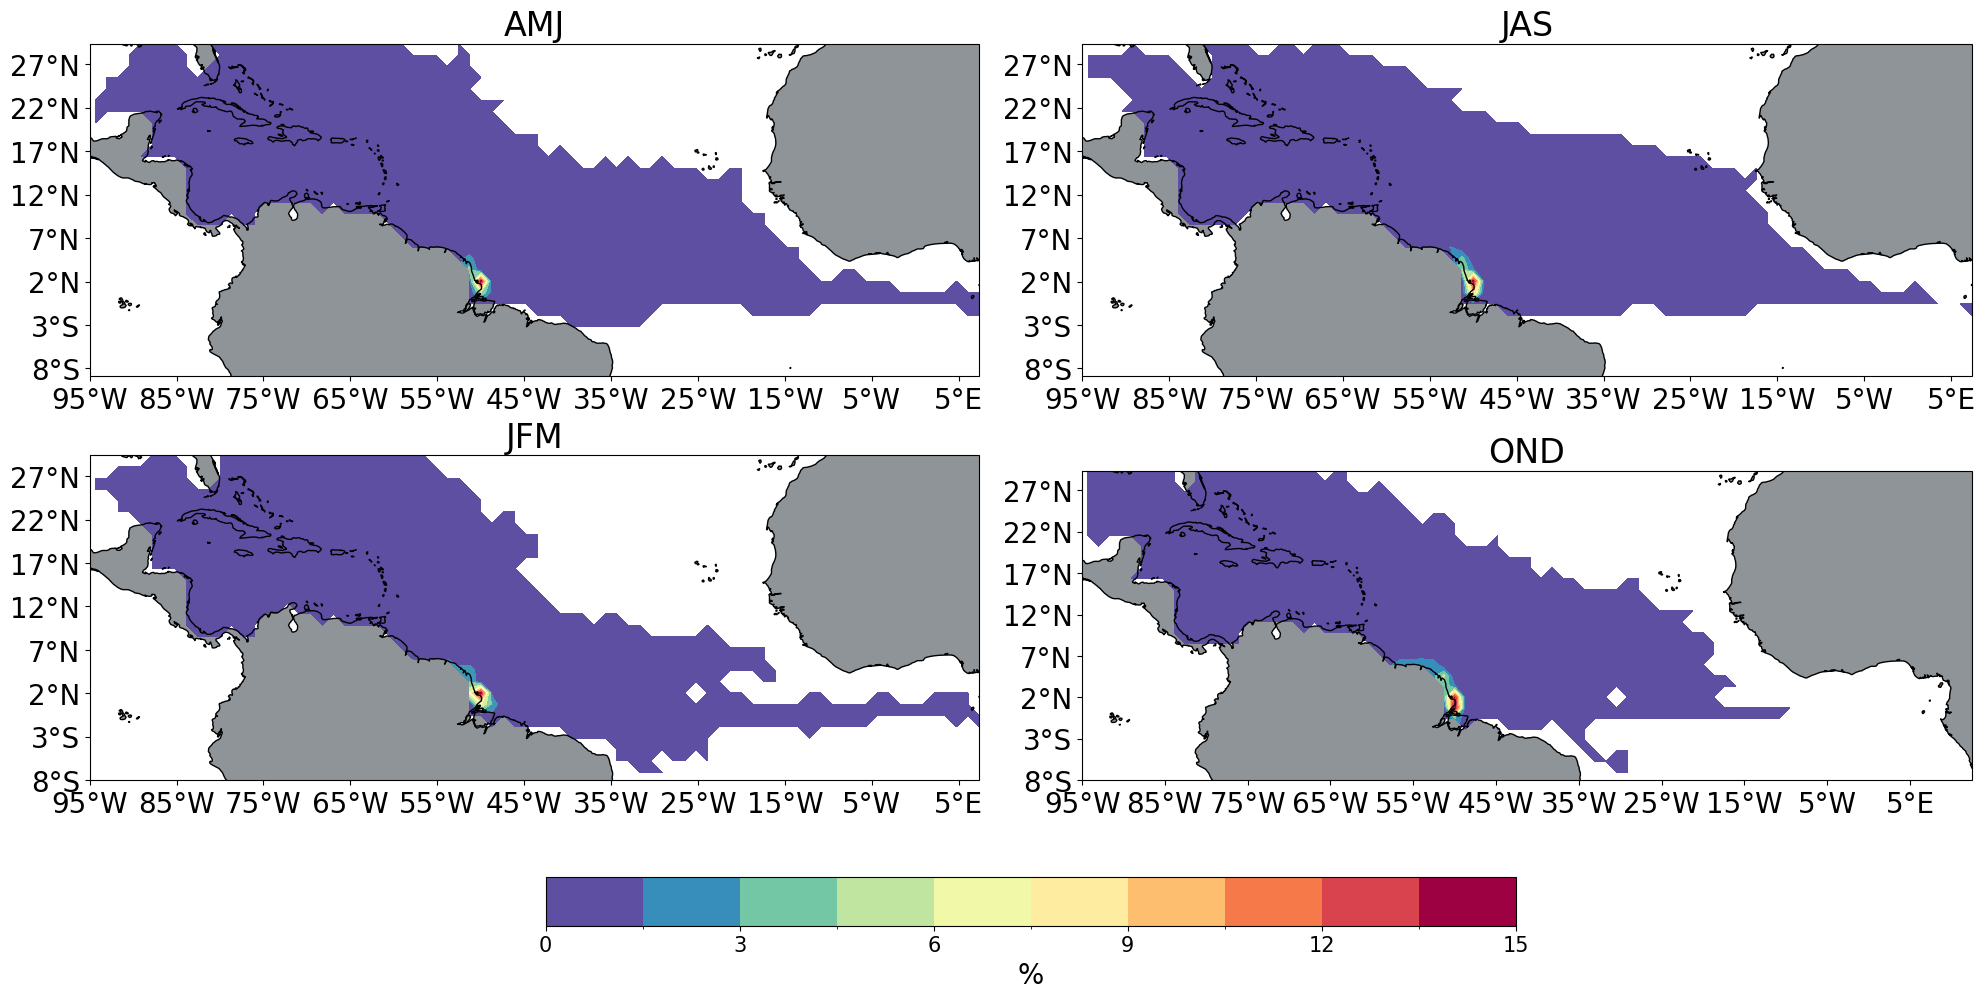

In [24]:
seasons = ['AMJ','JAS','JFM','OND']

fig, ax = plt.subplots(2, 2, figsize=(20, 10),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()


for i in range(len(seasons)):
    counts = hist_season.sel(season=str(seasons[i])).sum("obs")
    dd = (counts/counts.sum())*100
    # plot
    dd = dd.where(dd!=0,np.nan)
    pcm = dd.plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
        add_colorbar=False, cmap='Spectral_r',levels=11
    )

    ax[i].coastlines()
    ax[i].set_title(seasons[i], fontsize=24)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].tick_params(labelsize=20)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

fig.subplots_adjust(wspace=0.2, hspace=0.1)
plt.tight_layout()
# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10,
)
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_xlabel('%', fontsize=20)
# plt.savefig("seasonality_subplots_realtive_percentaje.png", dpi=300, bbox_inches="tight")
plt.show()

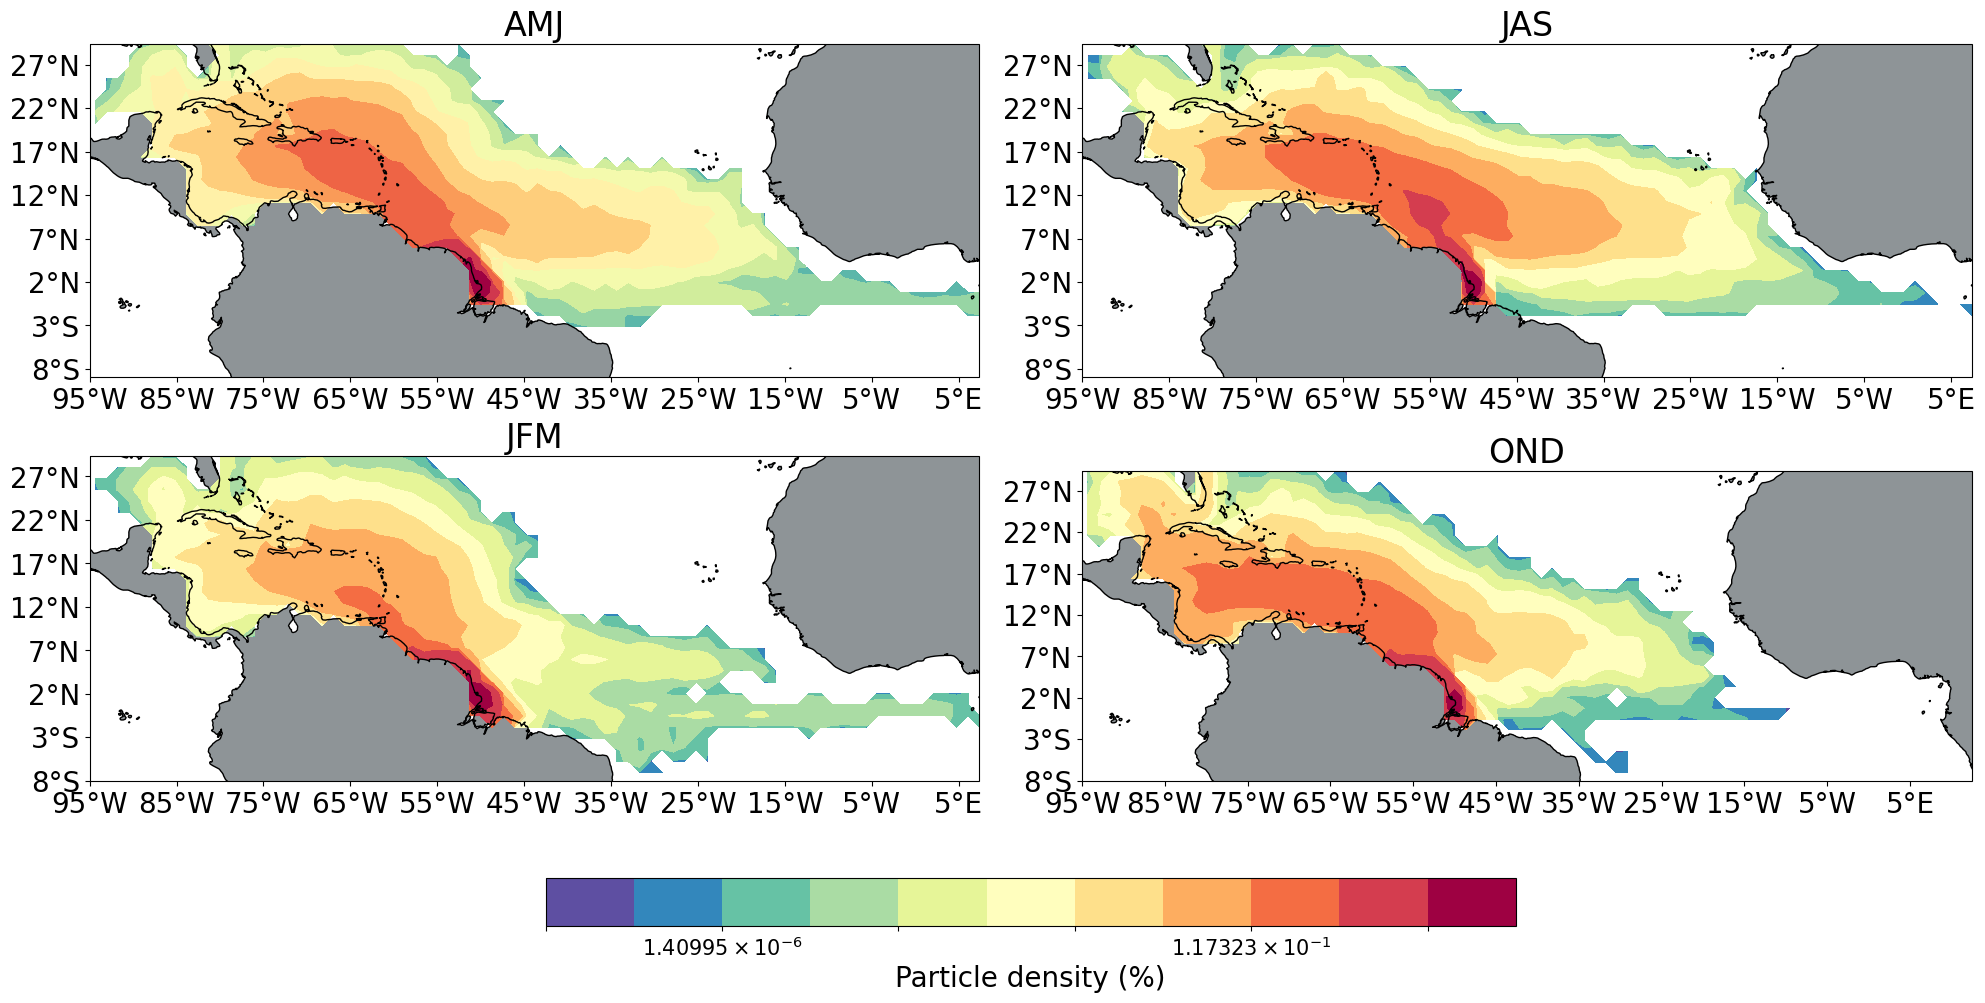

In [25]:
from matplotlib.colors import LogNorm
import numpy as np

seasons = ['AMJ','JAS','JFM','OND']

fig, ax = plt.subplots(2, 2, figsize=(20, 10),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

# Compute global min/max for consistent colorbar across seasons
all_dd = []
for i in range(len(seasons)):
    counts = hist_season.sel(season=str(seasons[i])).sum("obs")
    dd = (counts/counts.sum())*100
    dd = dd.where(dd != 0, np.nan)  # mask zeros
    all_dd.append(dd)

# Find global range (excluding NaN)
vmin = min([d.min().values for d in all_dd if not np.isnan(d.min().values)])
vmax = max([d.max().values for d in all_dd])

# Use log levels
levels = np.logspace(np.log10(vmin), np.log10(vmax), 12)

for i in range(len(seasons)):
    dd = all_dd[i]
    
    # plot with log-spaced levels
    pcm = dd.plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
        add_colorbar=False, cmap='Spectral_r',
        levels=levels,
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    ax[i].coastlines()
    ax[i].set_title(seasons[i], fontsize=24)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].tick_params(labelsize=20)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

fig.subplots_adjust(wspace=0.2, hspace=0.1)
plt.tight_layout()

# Shared colorbar with log scale
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10,
)
cbar.ax.tick_params(labelsize=15)
cbar.ax.set_xlabel('Particle density (%)', fontsize=20)

# plt.savefig("seasonality_subplots_true_percentage_log.png", dpi=300, bbox_inches="tight")
plt.show()

### STD of Particle cloud

In [26]:
hist_month_year = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/_hist_monthly_year.nc").compute().histogram_lon_lat
hist_month_year

<xarray.DataArray 'histogram_lon_lat' (obs: 37, lon: 79, lat: 29,
                                       start_month: 12, start_year: 21)> Size: 171MB
array([[[[[0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          ...,
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00]],

         [[0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
...
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00]],

         [[0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          ...,
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00],
          [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
           0.000e+00]]]]], shape=(37, 79, 29, 12, 21))
Coordinates:
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * start_year   (start_year) int64 168B 1993 1994 1995 1996 ... 2011 2012 2013
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


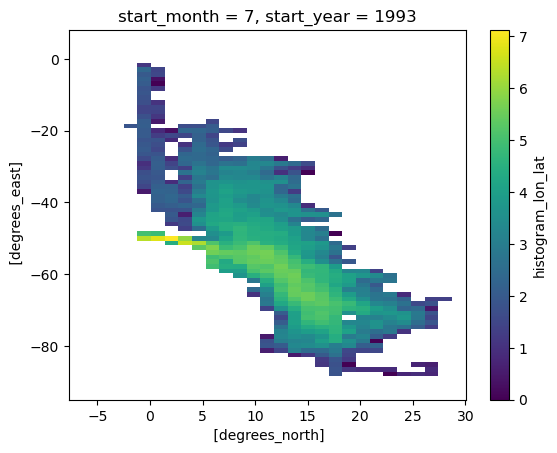

In [27]:
np.log10(hist_month_year.sel(start_month=7,start_year=1993).sum("obs")).plot()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


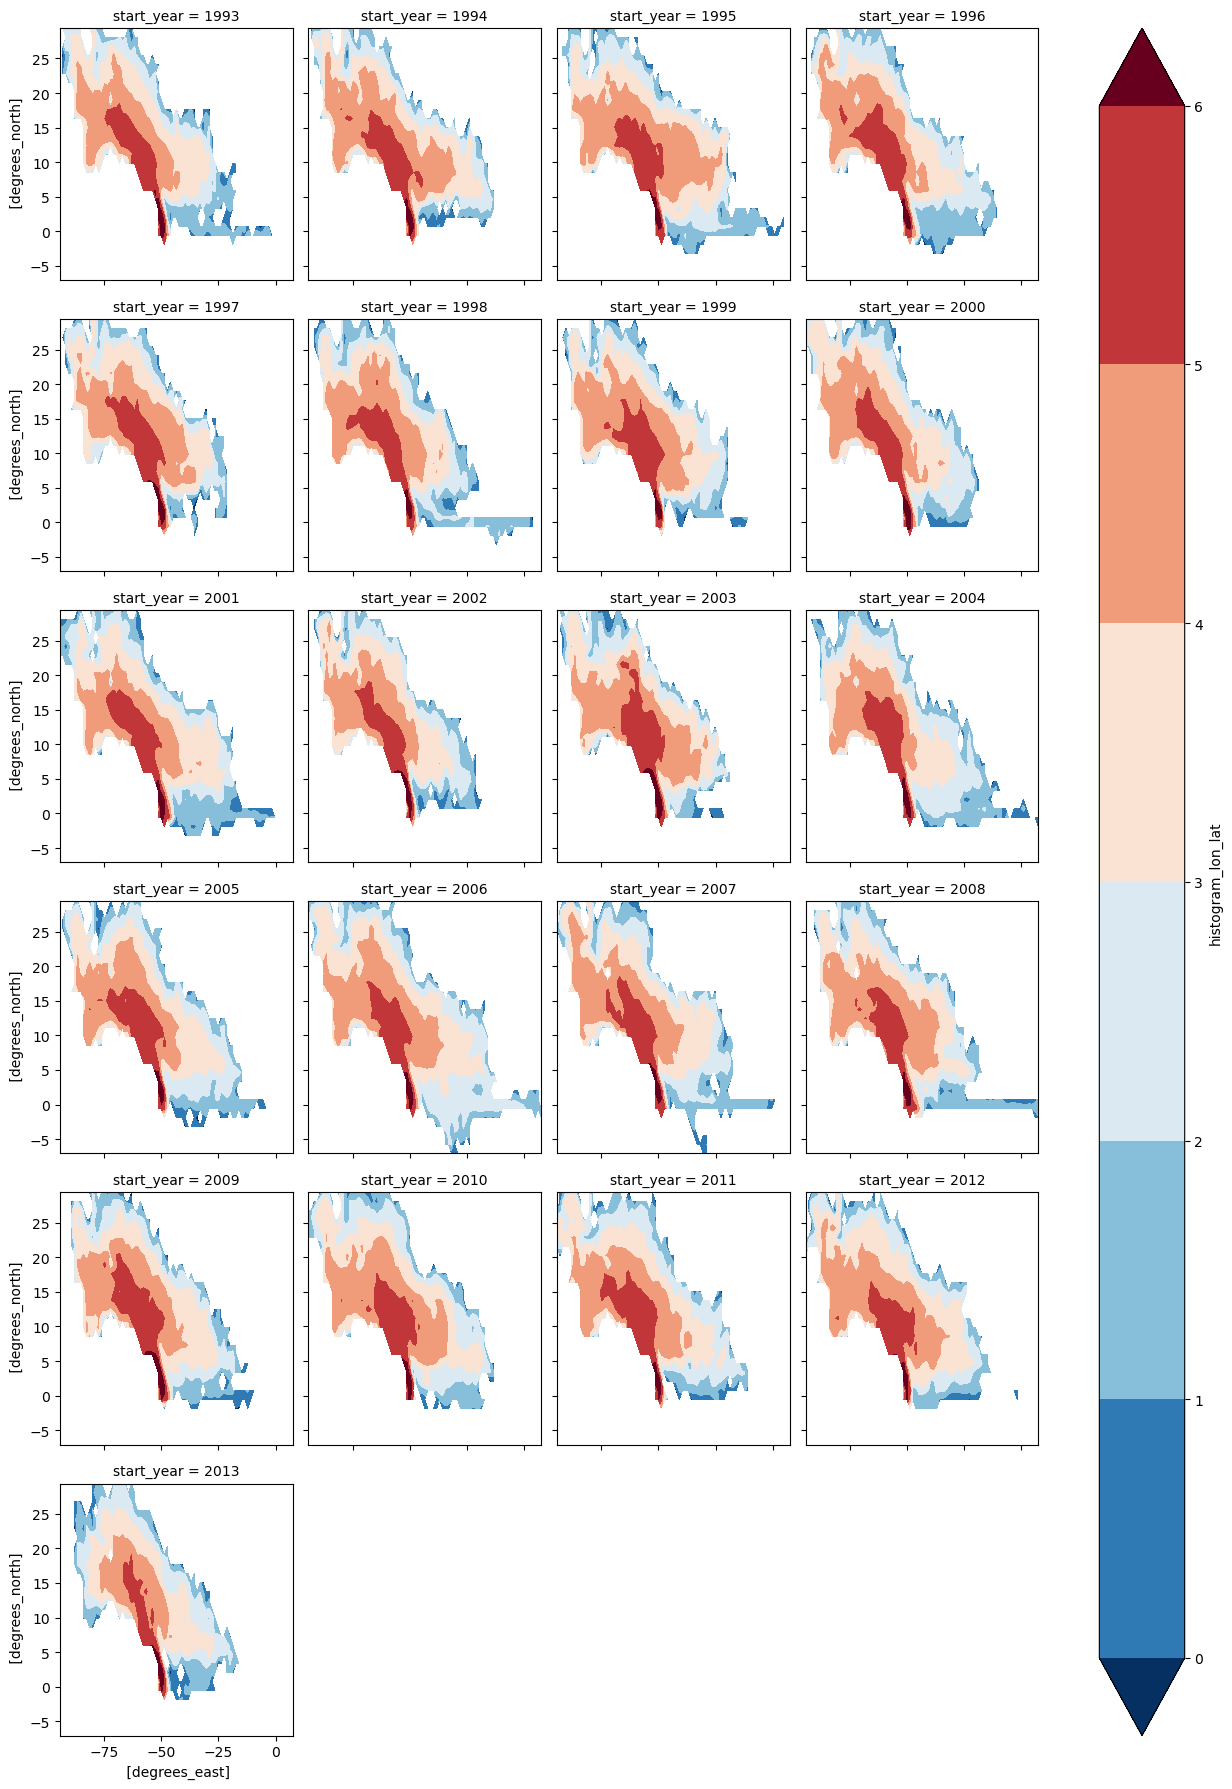

In [28]:
np.log10(hist_month_year.std('start_month').sum('obs')).plot.contourf(
    x="lon", y="lat", col="start_year", col_wrap=4,cmap='RdBu_r',robust=True)

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


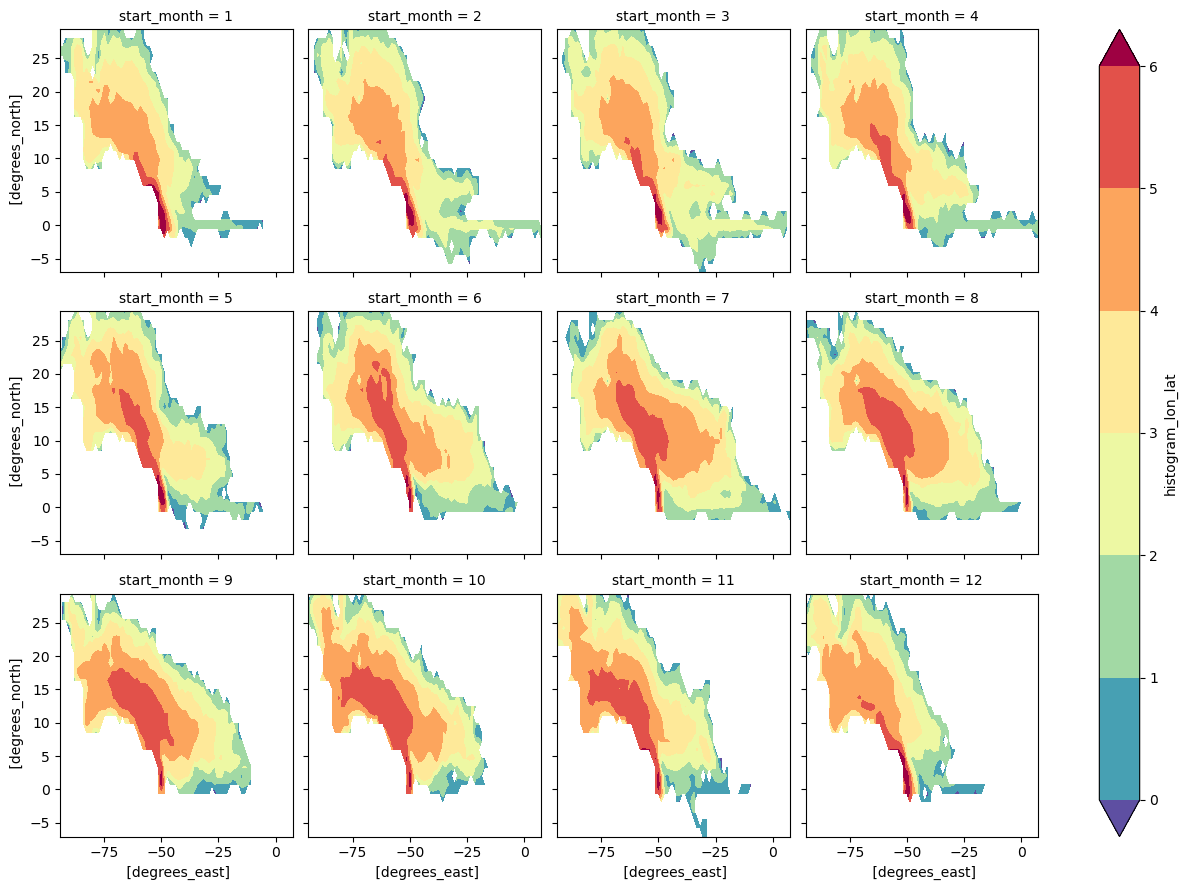

In [29]:
np.log10(hist_month_year.std('start_year').sum('obs')).plot.contourf(
    x="lon", y="lat", col="start_month", col_wrap=4,cmap='Spectral_r',robust=True)

#### Monthly Anomaly

In [30]:
hist_clim = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/_hist_month.nc").compute().histogram_lon_lat
hist_clim

<xarray.DataArray 'histogram_lon_lat' (start_month: 12, obs: 37, lon: 79,
                                       lat: 29)> Size: 8MB
array([[[[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
...
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,   83,    0,    0],
         [   0,    0,    0, ...,  736,  272,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    8,    0,    0],
         [   0,    0,    0, ...,  156,   19,    0],
         [   0,    0,    0, ..., 1216,  262,    8],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]]]],
      shape=(12, 37, 79, 29))
Coordinates:
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

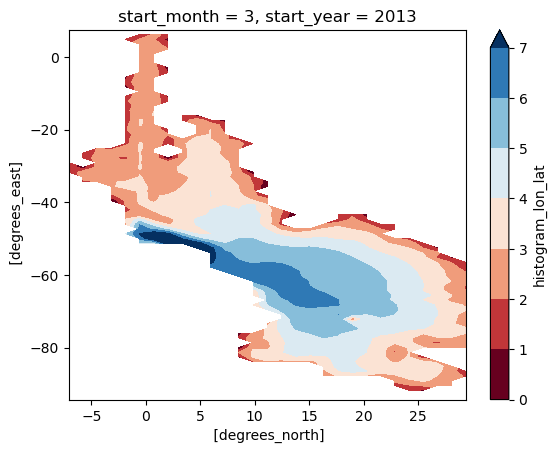

In [60]:
anom = (hist_month_year - hist_clim).isel(start_month=2,start_year=20).sum('obs')*-1
anom = np.log10(anom.where(anom!=0,np.nan))
anom.plot.contourf(robust=True,cmap='RdBu')